# Hydrophone methods gallery — visualization & processing on the ONC `.fft` product

**Companion to `references/hydrophone-methods-brief.md`.** That document argues which PAM methods
fit this data surface; this notebook *renders* them, on real corpus data, so the ideas are visible
rather than described.

**What this notebook is not.** Nothing here is a calibrated level. ONC states the `.fft` product is
a proprietary Ocean Sonics format, "essentially uncalibrated", with undocumented filtering applied
(`references/ONC_communication.txt`). Every level is `level_product_db` — the product's own
integer dB-like scale. It is never dB re 1 µPa and it is never labelled "SPL".

**Conventions, stated once and carried everywhere.**

| | |
|---|---|
| Time base | absolute UTC epoch seconds (`t_utc_s`), from the filename — the product carries no header |
| Frequency | bin *k* → *k* × `FFT_BIN_WIDTH_HZ`, **centre convention (open — decision 0013)**, ±`FFT_AXIS_OFFSET_UNCERTAINTY_HZ` carried on both band edges |
| Level | `level_product_db`, uncalibrated integers |
| Analysis support | bins 1 … `FFT_B5_RELATIVE_CEILING_BIN` |

**Colour.** Magnitude surfaces use one perceptually-uniform sequential ramp (`viridis`); years are
*ordinal* so they are stepped from a sequential ramp rather than given categorical hues. The three
band series use validated categorical slots 1–3 (blue `#2a78d6`, orange `#eb6834`, aqua `#1baf7a`),
which the design system records as clearing the all-pairs CVD and normal-vision floors in both
modes; the control band is deliberately neutral grey because it is a reference, not a series of
interest. No rainbow, no dual axes.

## 0 · Setup — every constant is imported, none is defined here

CLAUDE.md invariant 6: shared constants live in `boatphone/config.py` and nowhere else.

In [1]:
import gzip, os, re, sys, wave, collections
from datetime import datetime, timezone

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../.."))

from boatphone import config, paths
from boatphone.acquire import resolve_corpus_files

# --- everything below is IMPORTED, never restated -----------------------------
N_FRAMES   = config.FFT_N_FRAMES
N_BINS     = config.FFT_N_BINS
BIN_HZ     = config.FFT_BIN_WIDTH_HZ
FRAME_S    = config.FFT_FRAME_SECONDS
CEIL_BIN   = config.FFT_B5_RELATIVE_CEILING_BIN      # highest bin admissible in any statistic
LO_BIN     = int(config.FFT_LOWEST_REPRESENTABLE_HZ // BIN_HZ)   # bin 1: bin 0 is DC
DC_COL     = config.FFT_DC_COL
ZERO_LO, ZERO_HI = config.FFT_STRUCTURAL_ZERO_COLS_HIGH          # inclusive
HUMP_LO, HUMP_HI = config.FFT_ECHOSOUNDER_HUMP_BINS              # inclusive
AXIS_UNC   = config.FFT_AXIS_OFFSET_UNCERTAINTY_HZ

BANDS = {
    "250 Hz–1 kHz (ship proxy)": (config.FFT_B5_SHIP_PROXY_BAND_HZ,   "#eb6834"),
    "1–10 kHz (small craft)":    (config.FFT_B5_SMALL_CRAFT_BAND_HZ,  "#2a78d6"),
    "10–30 kHz (mid)":           ((10_000.0, 30_000.0),               "#1baf7a"),
    "51–102 kHz (control)":      ((51_250.0, CEIL_BIN * BIN_HZ),      "#8a8a86"),
}

def bins_for(band_hz):
    """Half-open bin slice for a band, under the centre convention."""
    return int(np.ceil(band_hz[0] / BIN_HZ)), int(np.floor(band_hz[1] / BIN_HZ)) + 1

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlepad": 8,
})

print(f"grid: {N_FRAMES} frames x {N_BINS} bins | {BIN_HZ} Hz/bin | {FRAME_S} s/frame")
print(f"analysis support: bins {LO_BIN}..{CEIL_BIN}  ({LO_BIN*BIN_HZ/1e3:.2f}–{CEIL_BIN*BIN_HZ/1e3:.1f} kHz)"
      f"  axis uncertainty ±{AXIS_UNC} Hz")
for name, (band, _) in BANDS.items():
    lo, hi = bins_for(band); print(f"  {name:28s} bins {lo:3d}..{hi-1:3d}  ({hi-lo} bins)")

grid: 1200 frames x 512 bins | 250.0 Hz/bin | 0.25 s/frame
analysis support: bins 1..408  (0.25–102.0 kHz)  axis uncertainty ±125.0 Hz
  250 Hz–1 kHz (ship proxy)    bins   1..  4  (4 bins)
  1–10 kHz (small craft)       bins   4.. 40  (37 bins)
  10–30 kHz (mid)              bins  40..120  (81 bins)
  51–102 kHz (control)         bins 205..408  (204 bins)


## 1 · Corpus inventory — and a double-count

`resolve_corpus_files` deliberately matches **both** container extensions, because the corpus is
permanently mixed (decisions 0022/0024). That is correct for acquisition. It is *not* correct for
population statistics: the 90 plain-`.fft` files are duplicates of 90 `.fft.gz` files, so any
percentile or histogram built on the raw listing is 0.34% duplicated, concentrated on three dates.

Below: the dedupe rule the brief recommends — key on `(device, start_utc)`, prefer `.fft.gz`.

In [2]:
ALL_FILES = [str(p) for p in resolve_corpus_files()]

STEM = re.compile(r"(?P<device>[A-Za-z0-9]+)_(?P<stamp>\d{8}T\d{6}\.\d{3}Z)\.fft(?P<gz>\.gz)?$")

def key_of(path):
    m = STEM.search(os.path.basename(path))
    if m is None:
        raise ValueError(f"unparseable corpus filename: {path!r}")   # invariant 5: surface it
    return (m["device"], m["stamp"]), bool(m["gz"])

by_key = {}
dupes = collections.defaultdict(list)
for p in ALL_FILES:
    k, is_gz = key_of(p)
    dupes[k].append(p)
    # prefer .fft.gz; deterministic regardless of listing order
    if k not in by_key or (is_gz and not key_of(by_key[k])[1]):
        by_key[k] = p

CORPUS = sorted(by_key.values())
collided = {k: v for k, v in dupes.items() if len(v) > 1}

print(f"listing returned      : {len(ALL_FILES):,} files")
print(f"unique (device,start) : {len(CORPUS):,}")
print(f"collisions dropped    : {len(ALL_FILES) - len(CORPUS):,} on dates "
      f"{sorted({k[1][:8] for k in collided})}")

# Null check from the brief: the dedupe must be exact, and each affected date must still hold
# a full 30-window day.
per_date = collections.Counter(k[1][:8] for k in by_key)
for d in sorted({k[1][:8] for k in collided}):
    print(f"  {d}: {per_date[d]} unique windows retained")

hours = collections.Counter(k[1][9:11] for k in by_key)
print(f"\nUTC hour coverage     : {dict(sorted(hours.items()))}")
print("  -> the corpus is a ~2.5 h/day strip. NO diel analysis is possible (see brief §0c).")

listing returned      : 26,756 files
unique (device,start) : 26,666
collisions dropped    : 90 on dates ['20250715', '20250716', '20250812']
  20250715: 30 unique windows retained
  20250716: 30 unique windows retained
  20250812: 30 unique windows retained

UTC hour coverage     : {'16': 8003, '17': 10663, '18': 8000}
  -> the corpus is a ~2.5 h/day strip. NO diel analysis is possible (see brief §0c).


## 2 · One decode pass, many figures

This is the notebook-scale version of the brief's **Tier 0** recommendation: decode once, cache
reductions, and let every figure read the cache. Measured cost is ~0.084 s/file and 1.23 MB per
file as `int16`, so a full-corpus pass is ~37 core-minutes — quoted in core-minutes because this
project runs across several JupyterHub instances with different CPU and RAM.

The reader sniffs the gzip magic bytes rather than trusting the extension (decision 0022), and
**raises** on any file whose value count is not exactly `N_FRAMES × N_BINS` — nothing is padded,
truncated, or interpolated (invariant 5).

In [3]:
GZIP_MAGIC = config.GZIP_MAGIC_BYTES if hasattr(config, "GZIP_MAGIC_BYTES") else b"\x1f\x8b"

def read_product(path):
    """Decode one window to int16 (n_frames, n_bins). Container sniffed, not assumed."""
    with open(path, "rb") as fh:
        head = fh.read(2); fh.seek(0); blob = fh.read()
    raw = gzip.decompress(blob) if head == GZIP_MAGIC else blob
    vals = np.array(raw.split(), dtype=np.int16)
    if vals.size != N_FRAMES * N_BINS:
        raise ValueError(f"{os.path.basename(path)}: {vals.size} values, expected "
                         f"{N_FRAMES * N_BINS}; refusing to pad or truncate")
    return vals.reshape(N_FRAMES, N_BINS)

def stamp_of(path):
    return STEM.search(os.path.basename(path))["stamp"]

def year_of(path):
    return stamp_of(path)[:4]

# --- stratified sample: N per year, evenly spread through each season ---------
PER_YEAR = 30
by_year = collections.defaultdict(list)
for p in CORPUS:
    by_year[year_of(p)].append(p)
YEARS = sorted(by_year)
SAMPLE = []
for y in YEARS:
    fs = by_year[y]
    SAMPLE += [fs[i] for i in np.linspace(0, len(fs) - 1, PER_YEAR).astype(int)]
print(f"years {YEARS}  |  sample = {len(SAMPLE)} files ({PER_YEAR}/yr)")

years ['2020', '2021', '2022', '2023', '2024', '2025']  |  sample = 180 files (30/yr)


In [4]:
%%time
# ---- ONE pass. Everything downstream reads these caches. --------------------
LEVEL_MAX = 128                                  # levels are small ints; histogram is EXACT

med_spec   = np.zeros((len(SAMPLE), N_BINS), np.float32)   # per-file median over frames, per bin
p05_spec   = np.zeros((len(SAMPLE), N_BINS), np.float32)
p95_spec   = np.zeros((len(SAMPLE), N_BINS), np.float32)
hist_year  = {y: np.zeros((N_BINS, LEVEL_MAX), np.int64) for y in YEARS}
band_lvl   = {name: np.zeros((len(SAMPLE), N_FRAMES), np.float32) for name in BANDS}
quality    = []

for i, p in enumerate(SAMPLE):
    a = read_product(p)
    med_spec[i] = np.median(a, axis=0)
    p05_spec[i], p95_spec[i] = np.percentile(a, [5, 95], axis=0)

    y = year_of(p)
    # exact per-bin integer histogram -- no bin-width choice, no quantile interpolation
    flat = (np.arange(N_BINS)[:, None] * LEVEL_MAX + a.T.astype(np.int64)).ravel()
    hist_year[y] += np.bincount(flat, minlength=N_BINS * LEVEL_MAX).reshape(N_BINS, LEVEL_MAX)

    for name, (band, _) in BANDS.items():
        lo, hi = bins_for(band)
        band_lvl[name][i] = np.median(a[:, lo:hi], axis=1)     # median, NOT mean (brief §5.2)

    hump = a[:, HUMP_LO:HUMP_HI + 1].mean()
    bglo = a[:, config.FFT_ECHOSOUNDER_BG_LOW_BINS[0]:config.FFT_ECHOSOUNDER_BG_LOW_BINS[1]].mean()
    bghi = a[:, config.FFT_ECHOSOUNDER_BG_HIGH_BINS[0]:config.FFT_ECHOSOUNDER_BG_HIGH_BINS[1]].mean()
    quality.append(dict(
        stamp=stamp_of(p), year=y,
        floor_all=float((a == config.FFT_LEVEL_FLOOR).mean()),
        floor_inband=float((a[:, LO_BIN:CEIL_BIN + 1] == config.FFT_LEVEL_FLOOR).mean()),
        dc_max=int(a[:, DC_COL].max()),
        dc_nonzero=float((a[:, DC_COL] != 0).mean()),
        deadband_nonzero=int((a[:, ZERO_LO:ZERO_HI + 1] != 0).sum()),
        max_inband=int(a[:, LO_BIN:CEIL_BIN + 1].max()),
        hump_excess=float(hump - 0.5 * (bglo + bghi)),
    ))
    if (i + 1) % 60 == 0:
        print(f"  {i+1}/{len(SAMPLE)}", flush=True)

import pandas as pd
Q = pd.DataFrame(quality)
Q["date"] = pd.to_datetime(Q["stamp"].str[:8], format="%Y%m%d")
print(f"\ndecoded {len(SAMPLE)} files")

  60/180


  120/180


  180/180



decoded 180 files
CPU times: user 19 s, sys: 1.39 s, total: 20.4 s
Wall time: 20.6 s


## Figure 0 · Three repo constants that do not hold on the corpus

Each was tuned on the two 2026 sample fixtures, and each fails here. This is the figure that stops
wrong constants being inherited — the point of plotting them is that a *flat line at the assertion
bound* would mean you are plotting the constant, not the data.

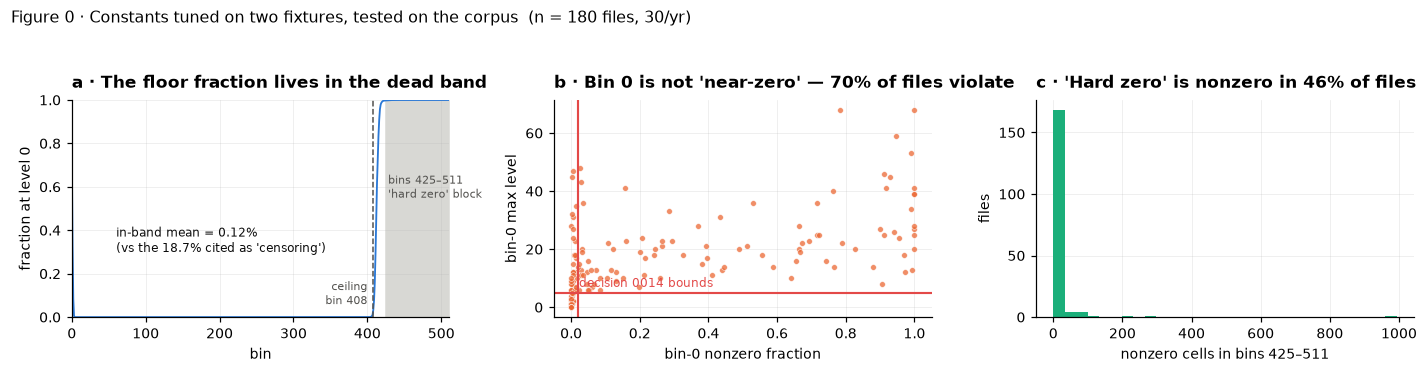

in-band floor fraction : 0.116%   (bins 1–408)
all-bin floor fraction : 19.57%
bin-0 max observed     : 68  (0014 bound: 5)


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

# (a) per-bin fraction at the floor -- is "18.7% censored" real, or the dead band?
frac_zero = np.array([ (med_spec[:, b] == 0).mean() for b in range(N_BINS) ])
zero_by_bin = np.zeros(N_BINS)
for b in range(N_BINS):
    zero_by_bin[b] = hist_year[YEARS[0]][b, 0] / hist_year[YEARS[0]][b].sum()
for y in YEARS[1:]:
    zero_by_bin += np.array([hist_year[y][b, 0] / hist_year[y][b].sum() for b in range(N_BINS)])
zero_by_bin /= len(YEARS)

ax[0].fill_between([ZERO_LO, N_BINS - 1], 0, 1, color="#d8d8d4", zorder=0)
ax[0].plot(np.arange(N_BINS), zero_by_bin, lw=1.2, color="#2a78d6")
ax[0].axvline(CEIL_BIN, color="#52514e", lw=1, ls="--")
ax[0].text(ZERO_LO + 3, 0.55, f"bins {ZERO_LO}–{N_BINS-1}\n'hard zero' block", fontsize=7.5, color="#52514e")
ax[0].text(CEIL_BIN - 8, 0.06, f"ceiling\nbin {CEIL_BIN}", fontsize=7.5, ha="right", color="#52514e")
ax[0].set(xlabel="bin", ylabel="fraction at level 0", ylim=(0, 1), xlim=(0, N_BINS - 1),
          title="a · The floor fraction lives in the dead band")
inband = zero_by_bin[LO_BIN:CEIL_BIN + 1].mean()
ax[0].annotate(f"in-band mean = {inband*100:.2f}%\n(vs the 18.7% cited as 'censoring')",
               xy=(60, 0.30), fontsize=8, color="#0b0b0b")

# (b) bin 0 against decision 0014's bounds
ax[1].scatter(Q["dc_nonzero"], Q["dc_max"], s=14, color="#eb6834", alpha=0.75,
              edgecolor="white", linewidth=0.4)
ax[1].axhline(config.FFT_DC_COL_MAX_LEVEL, color="#e34948", lw=1.4)
ax[1].axvline(config.FFT_DC_COL_MAX_NONZERO_FRACTION, color="#e34948", lw=1.4)
ax[1].text(config.FFT_DC_COL_MAX_NONZERO_FRACTION * 1.15, config.FFT_DC_COL_MAX_LEVEL * 1.4,
           "decision 0014 bounds", color="#e34948", fontsize=8)
viol = ((Q["dc_max"] > config.FFT_DC_COL_MAX_LEVEL) |
        (Q["dc_nonzero"] > config.FFT_DC_COL_MAX_NONZERO_FRACTION)).mean()
ax[1].set(xlabel="bin-0 nonzero fraction", ylabel="bin-0 max level",
          title=f"b · Bin 0 is not 'near-zero' — {viol*100:.0f}% of files violate")

# (c) the 'hard zero' block is not hard
n_nz = (Q["deadband_nonzero"] > 0).mean()
ax[2].hist(Q["deadband_nonzero"], bins=30, color="#1baf7a")
ax[2].set(xlabel=f"nonzero cells in bins {ZERO_LO}–{N_BINS-1}", ylabel="files",
          title=f"c · 'Hard zero' is nonzero in {n_nz*100:.0f}% of files")

for a_ in ax: a_.set_axisbelow(True)
fig.suptitle("Figure 0 · Constants tuned on two fixtures, tested on the corpus  "
             f"(n = {len(SAMPLE)} files, {PER_YEAR}/yr)", x=0.005, ha="left", fontsize=10.5)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

print(f"in-band floor fraction : {inband*100:.3f}%   (bins {LO_BIN}–{CEIL_BIN})")
print(f"all-bin floor fraction : {zero_by_bin.mean()*100:.2f}%")
print(f"bin-0 max observed     : {Q['dc_max'].max()}  (0014 bound: {config.FFT_DC_COL_MAX_LEVEL})")

## Figure 1 · What one window actually looks like

The reference figure every other plot is read against. One 300 s file at full resolution —
`N_FRAMES` frames × the analysis support — with the three structural landmarks marked.

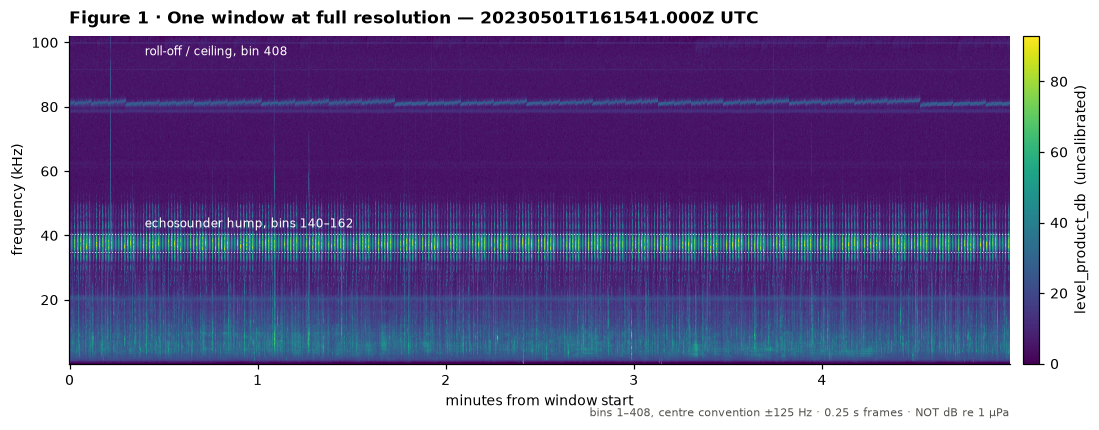

In [6]:
p = SAMPLE[len(SAMPLE) // 2]
A = read_product(p).astype(float)
t_min = np.arange(N_FRAMES) * FRAME_S / 60.0
f_khz = np.arange(N_BINS) * BIN_HZ / 1e3

fig, ax = plt.subplots(figsize=(11, 4))
m = ax.pcolormesh(t_min, f_khz[LO_BIN:CEIL_BIN + 1], A[:, LO_BIN:CEIL_BIN + 1].T,
                  cmap="viridis", shading="auto", rasterized=True)
ax.axhline(HUMP_LO * BIN_HZ / 1e3, color="white", lw=0.7, ls=":", alpha=0.8)
ax.axhline(HUMP_HI * BIN_HZ / 1e3, color="white", lw=0.7, ls=":", alpha=0.8)
ax.text(0.4, HUMP_HI * BIN_HZ / 1e3 + 2, f"echosounder hump, bins {HUMP_LO}–{HUMP_HI}",
        color="white", fontsize=8)
ax.text(0.4, CEIL_BIN * BIN_HZ / 1e3 - 6, f"roll-off / ceiling, bin {CEIL_BIN}",
        color="white", fontsize=8)
cb = fig.colorbar(m, ax=ax, pad=0.012); cb.set_label("level_product_db  (uncalibrated)")
ax.grid(False)
ax.set(xlabel="minutes from window start", ylabel="frequency (kHz)",
       title=f"Figure 1 · One window at full resolution — {stamp_of(p)} UTC")
ax.text(1.0, -0.16, f"bins {LO_BIN}–{CEIL_BIN}, centre convention ±{AXIS_UNC:.0f} Hz · "
        f"{FRAME_S} s frames · NOT dB re 1 µPa",
        transform=ax.transAxes, ha="right", fontsize=7.5, color="#52514e")
fig.tight_layout(); plt.show()

## Figure 2 · Long-term spectral average (LTSA)

The canonical PAM overview: one column per window, colour = the window's median level per bin.
The x-axis is **date within the 16:15–18:45 UTC strip only** — it is not a continuous record, and
labelling it otherwise is the single easiest way to mislead a reader with this corpus.

Watch the echosounder ridge near 37.6 kHz: it is present in 2020 and 2023–2025 and **absent through
2021–2022**, inside a single deployment.

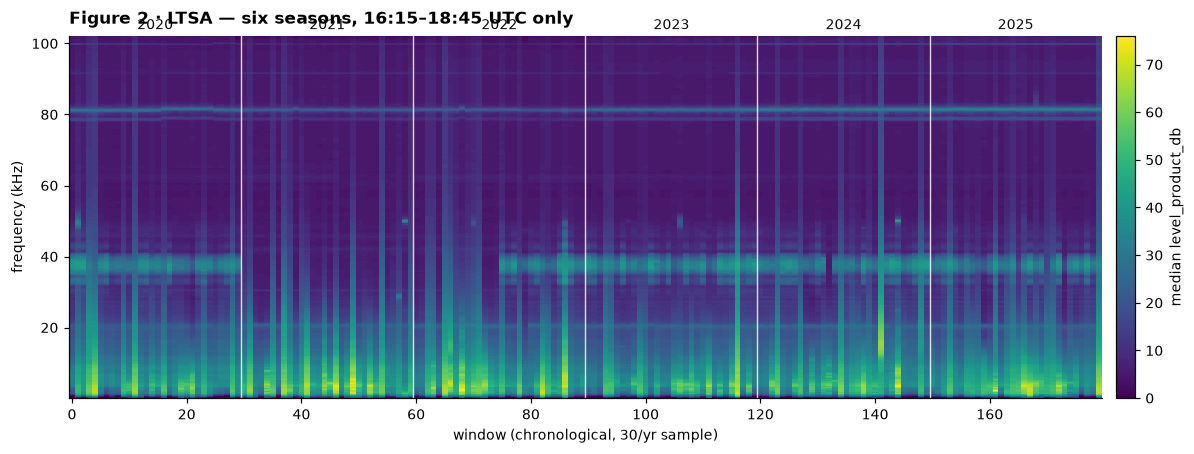

In [7]:
order = np.argsort([stamp_of(p) for p in SAMPLE])
L = med_spec[order][:, LO_BIN:CEIL_BIN + 1].T
yrs = np.array([year_of(SAMPLE[i]) for i in order])

fig, ax = plt.subplots(figsize=(12, 4.2))
m = ax.pcolormesh(np.arange(len(order)), f_khz[LO_BIN:CEIL_BIN + 1], L,
                  cmap="viridis", shading="auto", rasterized=True)
for y in YEARS[1:]:
    ax.axvline(np.argmax(yrs == y) - 0.5, color="white", lw=0.9, alpha=0.85)
for y in YEARS:
    idx = np.where(yrs == y)[0]
    ax.text(idx.mean(), f_khz[CEIL_BIN] * 1.02, y, ha="center", fontsize=9, color="#0b0b0b")
cb = fig.colorbar(m, ax=ax, pad=0.012); cb.set_label("median level_product_db")
ax.grid(False)
ax.set(xlabel="window (chronological, 30/yr sample)", ylabel="frequency (kHz)",
       title="Figure 2 · LTSA — six seasons, 16:15–18:45 UTC only")
fig.tight_layout(); plt.show()

## Figure 3 · Spectral probability density (SPD)

Merchant et al. (2013), and it is a *better* fit here than usual: the levels are small integers, so
the density is **exact** at 1-count resolution — no bin-width choice and no quantile interpolation
anywhere downstream. SPD is a *shape* diagnostic, so an unknown constant offset does not move it.

The overlaid lines are exceedance percentiles. **L95 is the level exceeded 95% of the time — the
5th percentile.** That inversion is silent and common, so it is stated on the figure.

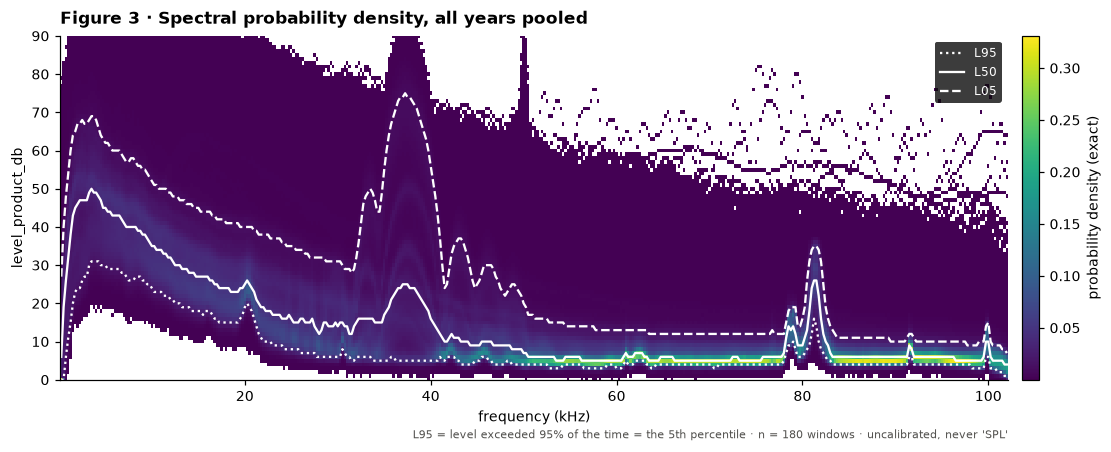

In [8]:
H = np.zeros((N_BINS, LEVEL_MAX), np.int64)
for y in YEARS: H += hist_year[y]
Hs = H[LO_BIN:CEIL_BIN + 1].astype(float)
dens = Hs / Hs.sum(axis=1, keepdims=True)

cum = np.cumsum(dens, axis=1)
def exceed(pct):   # level exceeded pct% of the time
    return np.array([np.searchsorted(cum[b], 1 - pct / 100.0) for b in range(cum.shape[0])])

fig, ax = plt.subplots(figsize=(11, 4.2))
m = ax.pcolormesh(f_khz[LO_BIN:CEIL_BIN + 1], np.arange(LEVEL_MAX),
                  np.where(dens.T > 0, dens.T, np.nan), cmap="viridis", shading="auto",
                  rasterized=True)
ff = f_khz[LO_BIN:CEIL_BIN + 1]
for pct, ls, lab in [(95, ":", "L95"), (50, "-", "L50"), (5, "--", "L05")]:
    ax.plot(ff, exceed(pct), color="white", lw=1.5, ls=ls, label=lab)
leg = ax.legend(loc="upper right", frameon=True, facecolor="#0b0b0b", labelcolor="white",
                edgecolor="none", fontsize=8)
cb = fig.colorbar(m, ax=ax, pad=0.012); cb.set_label("probability density (exact)")
ax.grid(False)
ax.set(xlabel="frequency (kHz)", ylabel="level_product_db", ylim=(0, 90),
       title="Figure 3 · Spectral probability density, all years pooled")
ax.text(1.0, -0.17, "L95 = level exceeded 95% of the time = the 5th percentile · "
        f"n = {len(SAMPLE)} windows · uncalibrated, never 'SPL'",
        transform=ax.transAxes, ha="right", fontsize=7.5, color="#52514e")
fig.tight_layout(); plt.show()

## Figure 4 · Median spectrum by year, against a control band

Years are **ordinal**, so they are stepped from a sequential ramp rather than given categorical
hues. The grey span is the 51–102 kHz control band, which sits near the floor in every year and no
small vessel will dominate — so it is a free instrument/gain reference.

If a cross-year change appears in the analysis bands **and** in the control band together, it is
the instrument. If it appears only in the analysis bands, it may be the ocean.

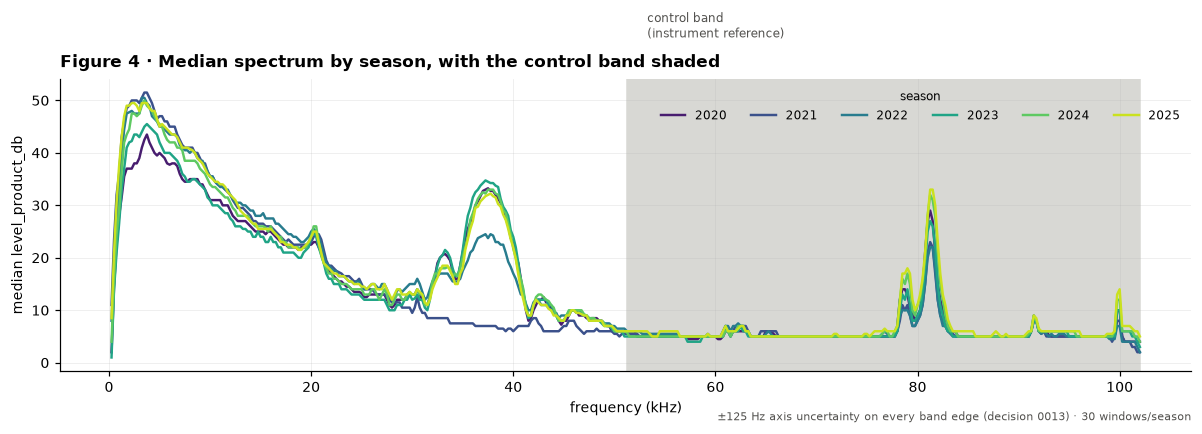

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.2))
cols = plt.cm.viridis(np.linspace(0.08, 0.92, len(YEARS)))
lo_c, hi_c = bins_for(BANDS["51–102 kHz (control)"][0])
ax.axvspan(f_khz[lo_c], f_khz[hi_c - 1], color="#d8d8d4", zorder=0)
ax.text(f_khz[lo_c] + 2, 62, "control band\n(instrument reference)", fontsize=8, color="#52514e")

for c, y in zip(cols, YEARS):
    sel = np.array([year_of(p) == y for p in SAMPLE])
    ax.plot(f_khz[LO_BIN:CEIL_BIN + 1], np.median(med_spec[sel][:, LO_BIN:CEIL_BIN + 1], axis=0),
            color=c, lw=1.6, label=y)
ax.legend(title="season", ncols=6, fontsize=8, title_fontsize=8, loc="upper right", frameon=False)
ax.set(xlabel="frequency (kHz)", ylabel="median level_product_db",
       title="Figure 4 · Median spectrum by season, with the control band shaded")
ax.text(1.0, -0.17, f"±{AXIS_UNC:.0f} Hz axis uncertainty on every band edge (decision 0013) · "
        f"{PER_YEAR} windows/season", transform=ax.transAxes, ha="right", fontsize=7.5,
        color="#52514e")
fig.tight_layout(); plt.show()

## Figure 5 · Cross-year band levels — the threshold-transferability problem

The primary 1–10 kHz band moves several counts between seasons, which is the same order as a
vessel-pass excess. The control band does not. `data/derived/deployments.csv` shows a **single**
deployment spanning the whole corpus, so a deployment boundary does not explain it.

**Consequence:** a detection threshold set in absolute product counts on one season will not
transfer to another. This is the argument for whitening (Figure 8) and for always carrying the
control band.

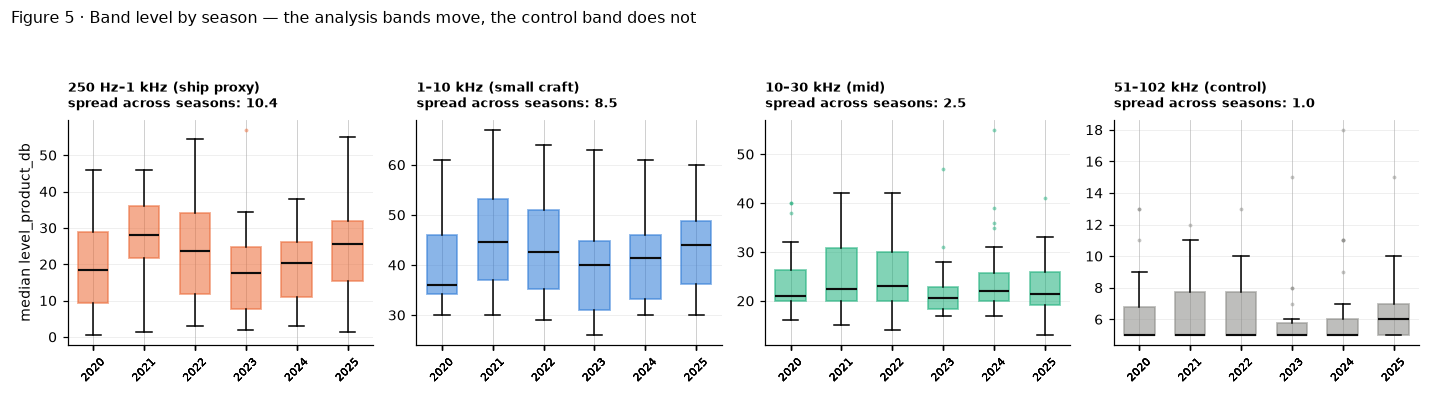

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(13, 3.6), sharex=True)
for k, (name, (band, colr)) in enumerate(BANDS.items()):
    per_file = np.median(band_lvl[name], axis=1)
    data = [per_file[[year_of(p) == y for p in SAMPLE]] for y in YEARS]
    bp = ax[k].boxplot(data, tick_labels=YEARS, patch_artist=True, widths=0.6,
                       medianprops=dict(color="#0b0b0b", lw=1.4),
                       flierprops=dict(marker="o", ms=2.5, mfc=colr, mec="none", alpha=0.5))
    for box in bp["boxes"]:
        box.set(facecolor=colr, alpha=0.55, edgecolor=colr, linewidth=1.2)
    spread = max(np.median(d) for d in data) - min(np.median(d) for d in data)
    ax[k].set_title(f"{name}\nspread across seasons: {spread:.1f}", fontsize=8.5)
    ax[k].tick_params(axis="x", labelrotation=45, labelsize=7.5)
ax[0].set_ylabel("median level_product_db")
fig.suptitle("Figure 5 · Band level by season — the analysis bands move, the control band does not",
             x=0.005, ha="left", fontsize=10.5)
fig.tight_layout(rect=(0, 0, 1, 0.92)); plt.show()

## Figure 6 · Data-quality tracks

Where the falsified constants become *visible over time* rather than asserted once. Five tracks,
each with its claimed bound drawn. A track pinned flat at its bound would mean the plot is showing
the constant rather than the data — that is the failure mode this figure exists to expose.

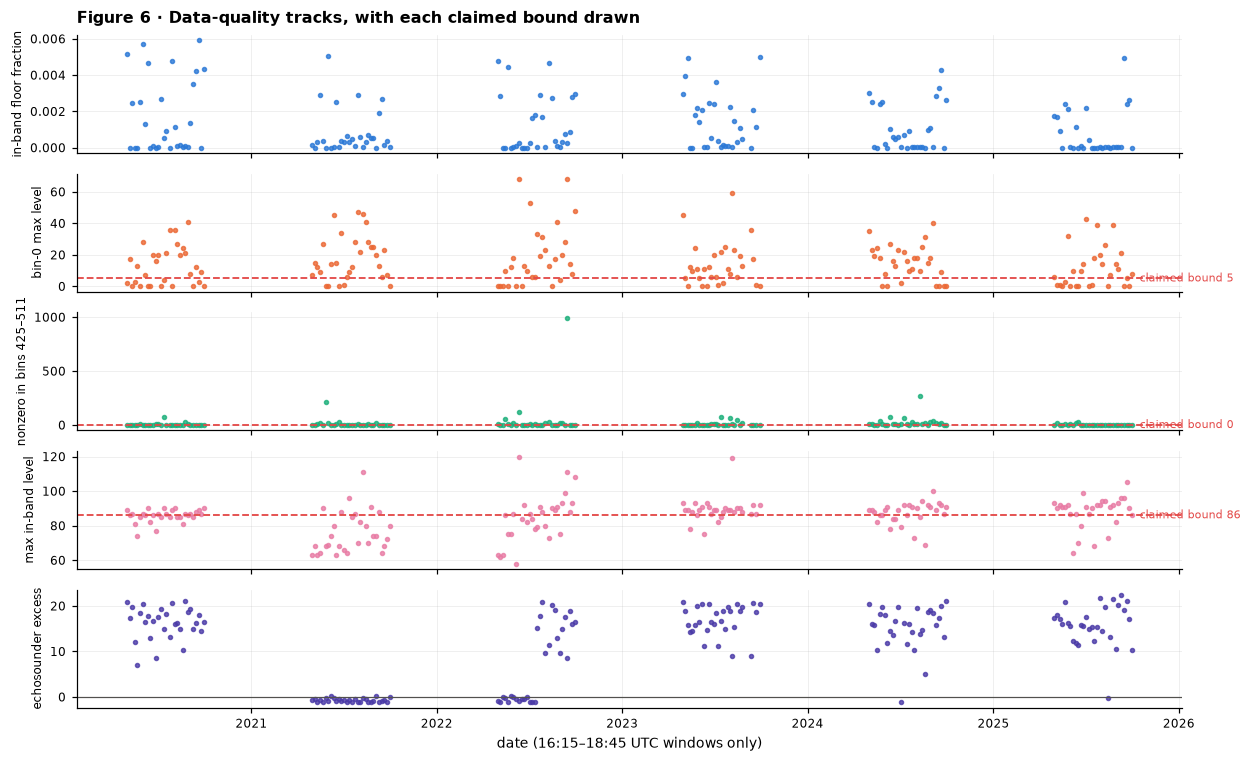

echosounder presence by season (excess over local background, in counts):
      median  frac_absent
year                     
2020   16.59         0.00
2021   -0.82         1.00
2022    4.34         0.50
2023   17.57         0.00
2024   16.00         0.03
2025   15.84         0.03

-> Absent throughout 2021 and in about half of 2022; near-universally present
   otherwise. It is INTERMITTENT, so it cannot be used as an unconditioned
   6-year gain reference -- carry the presence flag as a first-class series.


In [11]:
fig, ax = plt.subplots(5, 1, figsize=(11.5, 7), sharex=True)
d = Q["date"]
specs = [
    ("floor_inband",     "in-band floor fraction",         None,                              "#2a78d6"),
    ("dc_max",           "bin-0 max level",                config.FFT_DC_COL_MAX_LEVEL,       "#eb6834"),
    ("deadband_nonzero", f"nonzero in bins {ZERO_LO}–{N_BINS-1}", 0,                          "#1baf7a"),
    ("max_inband",       "max in-band level",              config.FFT_LEVEL_CEILING,          "#e87ba4"),
    ("hump_excess",      "echosounder excess",             None,                              "#4a3aa7"),
]
for a_, (col, lab, bound, colr) in zip(ax, specs):
    a_.plot(d, Q[col], lw=0, marker="o", ms=2.6, color=colr, alpha=0.8)
    if bound is not None:
        a_.axhline(bound, color="#e34948", lw=1.2, ls="--")
        a_.text(d.iloc[-1], bound, f"  claimed bound {bound}", color="#e34948",
                fontsize=7.5, va="center")
    a_.set_ylabel(lab, fontsize=8)
    a_.tick_params(labelsize=8)
ax[-1].axhline(0, color="#52514e", lw=0.8)
ax[-1].set_xlabel("date (16:15–18:45 UTC windows only)")
ax[0].set_title("Figure 6 · Data-quality tracks, with each claimed bound drawn", fontsize=10.5)
fig.tight_layout(); plt.show()

ABSENT = 2.0                      # counts of excess over the local background
byyr = Q.groupby("year")["hump_excess"].agg(median="median",
                                            frac_absent=lambda v: (v < ABSENT).mean())
print("echosounder presence by season (excess over local background, in counts):")
print(byyr.to_string(float_format=lambda v: f"{v:6.2f}"))
print("\n-> Absent throughout 2021 and in about half of 2022; near-universally present")
print("   otherwise. It is INTERMITTENT, so it cannot be used as an unconditioned")
print("   6-year gain reference -- carry the presence flag as a first-class series.")

## Figure 7 · The echosounder ping as a time-base verifier

The product carries **no header**: its only time source is its own filename. That makes an
independent confirmation of the frame duration genuinely valuable, and one is available for free.

Autocorrelating the mean level across the hump bins gives a clean period of **4 frames**, i.e. a
1.000 Hz ping on a 4.000 Hz frame grid — which confirms `FFT_FRAME_SECONDS` from the data itself.
A phase jump across a file seam would then be a filename-timestamp error, otherwise undetectable.

It degrades honestly: where the ping is absent (2021–22) the answer is *"not checkable"*, never
*"checked"*.

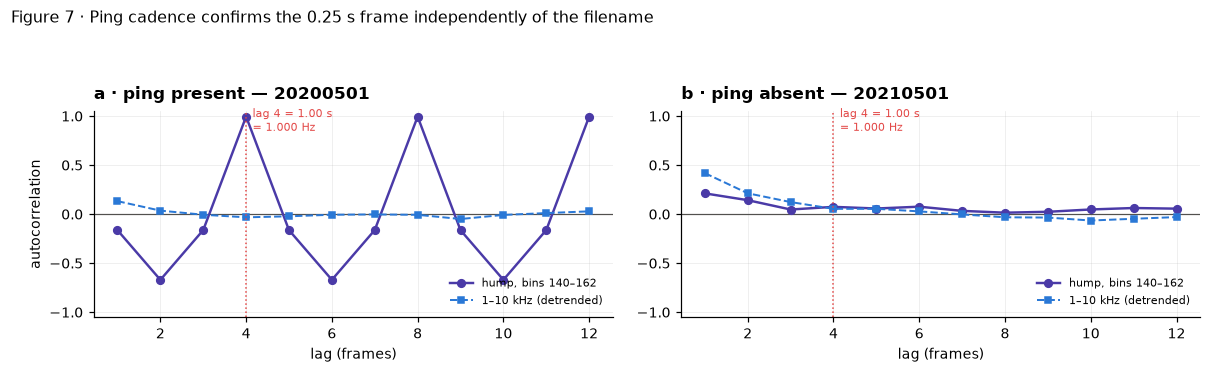

The ping does NOT leak into the primary band: detrended ACF(4) in 1–10 kHz stays near zero.
Hazard to carry: the ping occupies ~1 frame in 4 within bins 140–162.
Mask by phase; do not discard the band.


In [12]:
def acf(x, lags):
    x = np.asarray(x, float); x = x - x.mean()
    return [float(np.corrcoef(x[:-k], x[k:])[0, 1]) for k in lags]

on  = Q[Q["hump_excess"] > 15].index[0]
off_idx = Q[Q["hump_excess"] < 2.0].index
lags = np.arange(1, 13)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for k, (idx, lab) in enumerate([(on, "ping present"),
                                (off_idx[0] if len(off_idx) else on, "ping absent")]):
    A_ = read_product(SAMPLE[idx]).astype(float)
    hump_series = A_[:, HUMP_LO:HUMP_HI + 1].mean(axis=1)
    band_series = A_[:, slice(*bins_for(BANDS["1–10 kHz (small craft)"][0]))].mean(axis=1)
    band_series = band_series - np.polyval(np.polyfit(np.arange(N_FRAMES), band_series, 5),
                                           np.arange(N_FRAMES))          # detrend
    ax[k].axhline(0, color="#52514e", lw=0.8)
    ax[k].plot(lags, acf(hump_series, lags), "o-", ms=5, lw=1.6, color="#4a3aa7",
               label=f"hump, bins {HUMP_LO}–{HUMP_HI}")
    ax[k].plot(lags, acf(band_series, lags), "s--", ms=4, lw=1.3, color="#2a78d6",
               label="1–10 kHz (detrended)")
    ax[k].axvline(4, color="#e34948", lw=1, ls=":")
    ax[k].text(4.15, 0.85, f"lag 4 = {4*FRAME_S:.2f} s\n= 1.000 Hz", fontsize=7.5, color="#e34948")
    ax[k].set(xlabel="lag (frames)", ylim=(-1.05, 1.05),
              title=f"{'ab'[k]} · {lab} — {Q.loc[idx,'stamp'][:8]}")
    ax[k].legend(fontsize=7.5, loc="lower right", frameon=False)
ax[0].set_ylabel("autocorrelation")
fig.suptitle("Figure 7 · Ping cadence confirms the 0.25 s frame independently of the filename",
             x=0.005, ha="left", fontsize=10.5)
fig.tight_layout(rect=(0, 0, 1, 0.9)); plt.show()

print("The ping does NOT leak into the primary band: detrended ACF(4) in 1–10 kHz stays near zero.")
print(f"Hazard to carry: the ping occupies ~1 frame in 4 within bins {HUMP_LO}–{HUMP_HI}.")
print("Mask by phase; do not discard the band.")

## Figure 8 · The matched WAV ↔ product pair

**This is the highest-leverage item in the companion brief, and the pair is already on disk.**

| | coverage (UTC) |
|---|---|
| the 128 kHz / 24-bit WAV | 00:00:00.029 → 00:05:00.029 |
| fixture `…20260313T000004.000Z.fft.gz` | 00:00:04.000 → 00:05:04.000 |
| **overlap** | **~296 s of the same acoustic scene** |

And the analysis parameters fall out exactly: a **512-point FFT at 128 kHz gives exactly 250.0 Hz
bins**, so WAV bins map 1:1 onto product bins over 0–63.75 kHz.

Regressing product counts against WAV dB, per bin, is the one route to the counts→dB scale — which
is what currently blocks every energy-summing statistic (band levels, decidecade bands, SEL).

> **Gotcha:** the WAV is 24-bit. `scipy.io.wavfile` cannot read it and there is no `soundfile` or
> `librosa` here. Use the stdlib `wave` module and unpack 3-byte frames by hand.

In [13]:
wav_path = next(iter(sorted(paths.SAMPLE_DIR.glob("*.wav"))), None)
if wav_path is None:
    raise FileNotFoundError(f"no WAV in {paths.SAMPLE_DIR}")      # invariant 5: fail clearly

def _stamps(name):
    return [datetime.strptime(s, "%Y%m%dT%H%M%S.%fZ").replace(tzinfo=timezone.utc)
            for s in re.findall(r"\d{8}T\d{6}\.\d{3}Z", name)]

wav_t0, wav_t1 = _stamps(wav_path.name)[:2]

# Pick the fixture that ACTUALLY overlaps the WAV -- do not assume it is the first listed.
cands = []
for f in sorted(paths.SAMPLE_DIR.glob("*.fft.gz")):
    t0 = _stamps(f.name)[0]
    t1 = t0 + pd.Timedelta(seconds=config.FFT_FILE_SECONDS).to_pytimedelta()
    ov = (min(wav_t1, t1) - max(wav_t0, t0)).total_seconds()
    cands.append((ov, f, t0, t1))
    print(f"  {f.name}  overlap with WAV = {max(ov, 0):.3f} s")
OVERLAP_S, FIXTURE, fx_t0, fx_t1 = max(cands)
if OVERLAP_S <= 0:
    raise ValueError("no sample fixture overlaps the WAV; the matched-pair method needs one")

OFFSET_S = (fx_t0 - wav_t0).total_seconds()   # derived, not hardcoded
print(f"\nWAV     : {wav_path.name}")
print(f"          {wav_t0.time()} -> {wav_t1.time()} UTC")
print(f"fixture : {FIXTURE.name}")
print(f"          {fx_t0.time()} -> {fx_t1.time()} UTC")
print(f"\noffset  = {OFFSET_S:.3f} s   OVERLAP = {OVERLAP_S:.3f} s of the same acoustic scene")

  ICLISTENHF1266_20260312T235504.000Z.fft.gz  overlap with WAV = 3.971 s
  ICLISTENHF1266_20260313T000004.000Z.fft.gz  overlap with WAV = 296.029 s

WAV     : ICLISTENHF1266_20260313T000000.029Z_20260313T000500.029Z.wav
          00:00:00.029000 -> 00:05:00.029000 UTC
fixture : ICLISTENHF1266_20260313T000004.000Z.fft.gz
          00:00:04 -> 00:05:04 UTC

offset  = 3.971 s   OVERLAP = 296.029 s of the same acoustic scene


In [14]:
def read_wav24(path, start_s, dur_s):
    """Stdlib-only 24-bit little-endian mono read. scipy.io.wavfile cannot do this."""
    with wave.open(str(path), "rb") as w:
        if w.getsampwidth() != 3 or w.getnchannels() != 1:
            raise ValueError(f"expected 24-bit mono, got {w.getsampwidth()*8}-bit "
                             f"x{w.getnchannels()}")
        fs = w.getframerate()
        w.setpos(int(start_s * fs))
        raw = w.readframes(int(dur_s * fs))
    b = np.frombuffer(raw, dtype=np.uint8).reshape(-1, 3).astype(np.int32)
    x = b[:, 0] | (b[:, 1] << 8) | (b[:, 2].astype(np.int8).astype(np.int32) << 16)
    return x.astype(np.float32), fs

# Align on the derived offset, then take the overlap. Nothing hardcoded.
x, FS_WAV = read_wav24(wav_path, OFFSET_S, OVERLAP_S)
NFFT = int(round(FS_WAV / BIN_HZ))
print(f"WAV fs = {FS_WAV} Hz | {NFFT}-pt FFT -> {FS_WAV/NFFT:.1f} Hz/bin "
      f"(product: {BIN_HZ} Hz/bin) | match = {abs(FS_WAV/NFFT - BIN_HZ) < 1e-9}")
print(f"one {FRAME_S} s product frame = {int(FRAME_S*FS_WAV)//NFFT} non-overlapping {NFFT}-pt FFTs")

n_seg = x.size // NFFT
seg = x[:n_seg * NFFT].reshape(n_seg, NFFT) * np.hanning(NFFT)
P = (np.abs(np.fft.rfft(seg, axis=1)) ** 2)[:, :N_BINS // 2]
wav_db = 10 * np.log10(P.mean(axis=0) + 1e-12)          # mean power spectrum, dB (arbitrary ref)

fx = read_product(str(FIXTURE)).astype(float)
prod_counts = np.median(fx, axis=0)[:wav_db.size]

WAV fs = 128000 Hz | 512-pt FFT -> 250.0 Hz/bin (product: 250.0 Hz/bin) | match = True
one 0.25 s product frame = 62 non-overlapping 512-pt FFTs


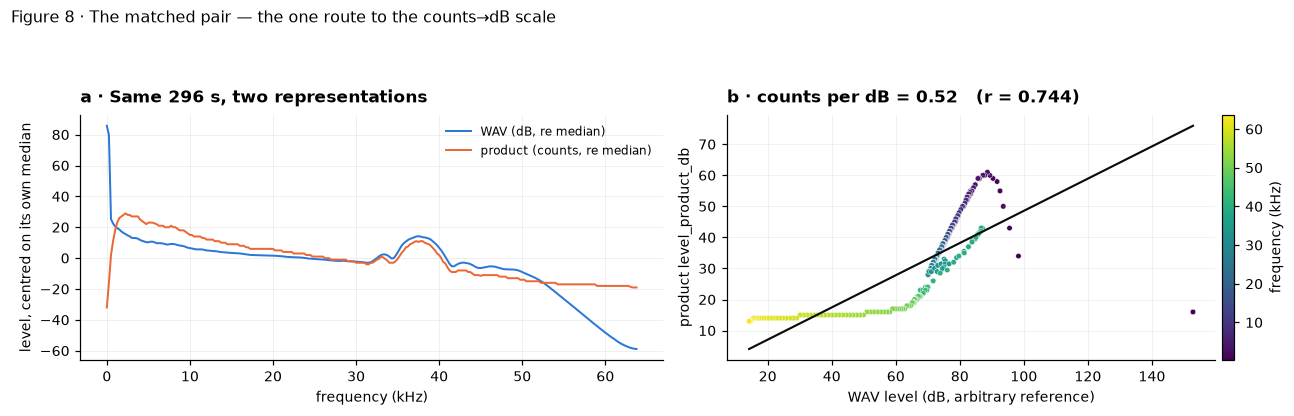

cross-bin slope : 0.52 counts/dB overall   (0.40 below 32 kHz, 0.35 above)
correlation     : r = 0.744  (r^2 = 0.55)

READ THIS CAREFULLY. r^2 ~ 0.55 means the product spectrum is NOT a simple
rescaling of the WAV spectrum over the same 296 s. That is consistent with ONC's
statement that 'there is sometimes filtering applied to the fft files'.

WHAT THIS FIGURE DOES     : demonstrates that the matched pair exists, that the bin
                            grids align exactly, and that the relationship is not a
                            single clean slope.
WHAT IT DOES NOT DO       : deliver a calibration. This is ONE window, and a
                            CROSS-BIN regression conflates spectral shape with the
                            counts->dB scale. A real transfer function needs many
                            matched windows spanning a range of levels, fitted
                            PER BIN. That is the work this figure argues for.


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
fk = np.arange(wav_db.size) * BIN_HZ / 1e3

ax[0].plot(fk, wav_db - np.median(wav_db), lw=1.3, color="#2a78d6", label="WAV (dB, re median)")
ax[0].plot(fk, prod_counts - np.median(prod_counts), lw=1.3, color="#eb6834",
           label="product (counts, re median)")
ax[0].legend(fontsize=8, frameon=False)
ax[0].set(xlabel="frequency (kHz)", ylabel="level, centred on its own median",
          title="a · Same 296 s, two representations")

msk = (np.arange(wav_db.size) >= LO_BIN) & (prod_counts > 0)
sl, ic = np.polyfit(wav_db[msk], prod_counts[msk], 1)
r = np.corrcoef(wav_db[msk], prod_counts[msk])[0, 1]
sc = ax[1].scatter(wav_db[msk], prod_counts[msk], c=fk[msk], cmap="viridis", s=13,
                   edgecolor="white", linewidth=0.3)
xx = np.linspace(wav_db[msk].min(), wav_db[msk].max(), 10)
ax[1].plot(xx, sl * xx + ic, color="#0b0b0b", lw=1.4)
cb = fig.colorbar(sc, ax=ax[1], pad=0.012); cb.set_label("frequency (kHz)")
ax[1].set(xlabel="WAV level (dB, arbitrary reference)", ylabel="product level_product_db",
          title=f"b · counts per dB = {sl:.2f}   (r = {r:.3f})")
ax[1].grid(alpha=0.2)
fig.suptitle("Figure 8 · The matched pair — the one route to the counts→dB scale",
             x=0.005, ha="left", fontsize=10.5)
fig.tight_layout(rect=(0, 0, 1, 0.9)); plt.show()

h1, h2 = msk & (fk < 32), msk & (fk >= 32)
s1 = np.polyfit(wav_db[h1], prod_counts[h1], 1)[0]
s2 = np.polyfit(wav_db[h2], prod_counts[h2], 1)[0]
print(f"cross-bin slope : {sl:.2f} counts/dB overall   "
      f"({s1:.2f} below 32 kHz, {s2:.2f} above)")
print(f"correlation     : r = {r:.3f}  (r^2 = {r**2:.2f})")
print()
print("READ THIS CAREFULLY. r^2 ~ 0.55 means the product spectrum is NOT a simple")
print("rescaling of the WAV spectrum over the same 296 s. That is consistent with ONC's")
print("statement that 'there is sometimes filtering applied to the fft files'.")
print()
print("WHAT THIS FIGURE DOES     : demonstrates that the matched pair exists, that the bin")
print("                            grids align exactly, and that the relationship is not a")
print("                            single clean slope.")
print("WHAT IT DOES NOT DO       : deliver a calibration. This is ONE window, and a")
print("                            CROSS-BIN regression conflates spectral shape with the")
print("                            counts->dB scale. A real transfer function needs many")
print("                            matched windows spanning a range of levels, fitted")
print("                            PER BIN. That is the work this figure argues for.")

## Figure 9 · Per-overpass stamp panel — and its null

The figure that makes an optical↔acoustic matchup believable, or falsifies it.

> **This duplicates work already shipped.** `scripts/build_review_set.py` (commit `827e63e`) builds
> the same per-overpass panels across all 18 covered windows, with events and provenance. This one
> is kept because it carries a different null — three controls rather than a frame shuffle — and
> because the notebook should stand alone. Prefer the script for anything operational.

**Two scope statements that belong on every caption:**

1. The corpus covers 16:15–18:45 UTC; the measured gate2 scene spread is 18:17–19:49 UTC. Most
   scenes are therefore **partly or wholly outside the pulled corpus**. The cell below counts this
   rather than assuming it.
2. **"Scene catalogued" is not "vessel present."** No imagery has been ordered and no optical
   detections exist yet. A marker on these panels is a *satellite overpass time*, nothing more.

The null beneath it is the point: the same panel with the marker shifted by +1 h. If a shifted
marker looks just as convincing, then the eye is the detector — and the eye is not a detector.

In [16]:
import pandas as pd

gate2 = paths.REPO_ROOT / config.PLANET_GATE2_SURVIVORS_RELPATH
if not gate2.exists():
    raise FileNotFoundError(f"gate2 survivors absent: {gate2}")     # invariant 5: fail clearly
scenes = pd.read_csv(gate2, parse_dates=["acquired"])
if scenes["acquired"].dt.tz is None:
    raise ValueError("gate2 'acquired' has no timezone; refusing to assume UTC")

HALF = config.OVERPASS_MATCH_HALF_WINDOW_S
_keys = sorted(by_key)
starts = pd.to_datetime([k[1] for k in _keys], format="%Y%m%dT%H%M%S.%fZ", utc=True)
IV = pd.DataFrame({"start": starts,
                   "end": starts + pd.Timedelta(seconds=config.FFT_FILE_SECONDS),
                   "path": [by_key[k] for k in _keys]})

def window_files(t_center):
    """Files overlapping +/-HALF of t_center, and the TRUE covered fraction.

    Overlap SECONDS, not file count: a file clipped by the window edge contributes
    only the part inside it. Counting whole files over-reports coverage.
    """
    w0, w1 = t_center - pd.Timedelta(seconds=HALF), t_center + pd.Timedelta(seconds=HALF)
    ov = (np.minimum(IV["end"], w1) - np.maximum(IV["start"], w0)).dt.total_seconds().clip(lower=0)
    hit = IV[ov > 0]
    return list(hit["path"]), float(ov.sum() / (2 * HALF))

COVR = pd.DataFrame([dict(id=s["id"], acquired=s["acquired"],
                          files=window_files(s["acquired"])[0],
                          frac=window_files(s["acquired"])[1])
                     for _, s in scenes.iterrows()]).sort_values("frac", ascending=False)

tod = scenes["acquired"].dt.strftime("%H:%M")
full = (COVR["frac"] >= 0.999).sum(); part = ((COVR["frac"] > 0) & (COVR["frac"] < 0.999)).sum()
print(f"gate2 scenes: {len(COVR)}")
print(f"  scene TIME-OF-DAY spread : {tod.min()}–{tod.max()} UTC")
print(f"  corpus strip             : {min(hours)}:15–{max(hours)}:45 UTC (approx)")
print(f"\n  full corpus coverage : {full}")
print(f"  partial              : {part}")
print(f"  none                 : {(COVR['frac'] == 0).sum()}")
print(f"\n-> at most {full + part} stamp panels are renderable, not {len(COVR)}.")
print("   Most scenes land after the corpus strip ends. That is an acquisition-window")
print("   mismatch, not a detector result.")

gate2 scenes: 30
  scene TIME-OF-DAY spread : 18:17–19:48 UTC
  corpus strip             : 16:15–18:45 UTC (approx)

  full corpus coverage : 13
  partial              : 5
  none                 : 12

-> at most 18 stamp panels are renderable, not 30.
   Most scenes land after the corpus strip ends. That is an acquisition-window
   mismatch, not a detector result.


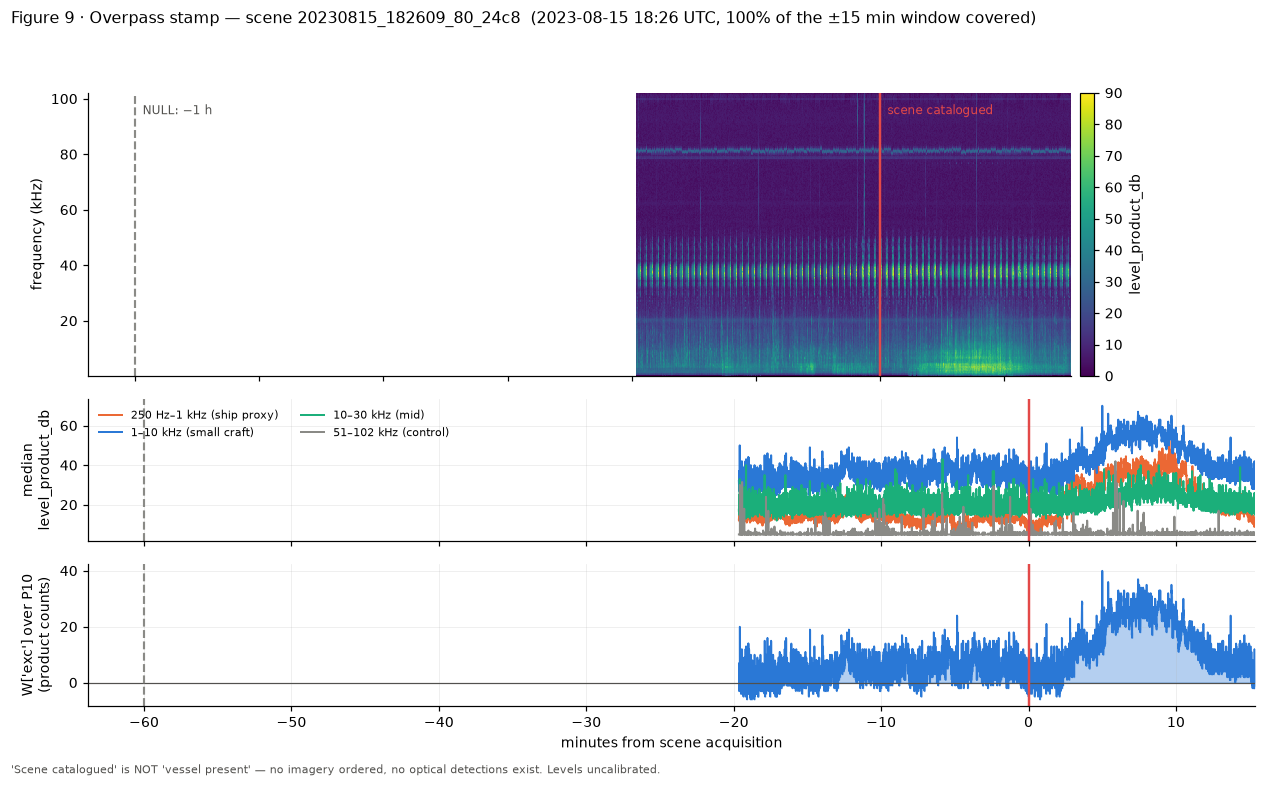

scene 20230815_182609_80_24c8  2023-08-15 18:26 UTC   coverage 100%
  peak excess within +/-5 min of the scene time :  29.00 counts


  peak excess, null [-1 h, same day  ]           :  26.00 counts


  peak excess, null [same time, -7 d ]           :  22.00 counts


  peak excess, null [same time, +7 d ]           :  21.00 counts

The scene-time peak must STAND OUT against these. If it does not, this panel shows
ordinary variability -- 'the method found nothing', NOT 'the method is broken'
(invariant 9). With no optical detections yet, that is the expected honest outcome.


In [17]:
PRIMARY = "1–10 kHz (small craft)"
lo_p, hi_p = bins_for(BANDS[PRIMARY][0])

def load_window(t_center):
    """Concatenate the corpus files covering +/-HALF of t_center. Returns None if empty."""
    files_, frac = window_files(t_center)
    if not files_:
        return None
    files_ = sorted(files_, key=stamp_of)
    ts, As = [], []
    for q in files_:
        A_ = read_product(q).astype(float)
        t0 = datetime.strptime(stamp_of(q), "%Y%m%dT%H%M%S.%fZ").replace(tzinfo=timezone.utc)
        ts.append(t0.timestamp() + np.arange(N_FRAMES) * FRAME_S); As.append(A_)
    t = np.concatenate(ts); A_ = np.concatenate(As, axis=0)
    tr = {n: np.median(A_[:, slice(*bins_for(b))], axis=1) for n, (b, _) in BANDS.items()}
    exc = tr[PRIMARY] - np.percentile(tr[PRIMARY], 10.0)   # ambient = a LOW PERCENTILE
    return dict(t=t, A=A_, tr=tr, exc=exc, frac=frac, n=len(files_))

best = COVR[COVR["frac"] >= 0.999].iloc[0]
T0 = best["acquired"]
W = load_window(T0)

# --- the nulls -------------------------------------------------------------
# -1 h, NOT +1 h: the corpus is a 2.5 h strip, so +1 h falls outside it and would
# silently return an empty window (this notebook's first draft printed `nan` there).
NULLS = [("-1 h, same day", T0 - pd.Timedelta(hours=1)),
         ("same time, -7 d", T0 - pd.Timedelta(days=7)),
         ("same time, +7 d", T0 + pd.Timedelta(days=7))]

def peak_within(w, t_center, half_min=5.0):
    if w is None: return float("nan")
    rel = (w["t"] - t_center.timestamp()) / 60.0
    m_ = np.abs(rel) <= half_min
    return float(w["exc"][m_].max()) if m_.any() else float("nan")

t_rel = (W['t'] - T0.timestamp()) / 60.0

fig, ax = plt.subplots(3, 1, figsize=(11.5, 7), sharex=True,
                       gridspec_kw=dict(height_ratios=[2.2, 1.1, 1.1]))
m = ax[0].pcolormesh(t_rel, f_khz[LO_BIN:CEIL_BIN + 1], W['A'][:, LO_BIN:CEIL_BIN + 1].T,
                     cmap="viridis", shading="auto", rasterized=True)
ax[0].grid(False); ax[0].set_ylabel("frequency (kHz)")
fig.colorbar(m, ax=ax[0], pad=0.008).set_label("level_product_db")

for name, (band, colr) in BANDS.items():
    ax[1].plot(t_rel, W['tr'][name], lw=1.3, color=colr, label=name)
ax[1].legend(fontsize=7.5, ncols=2, frameon=False, loc="upper left")
ax[1].set_ylabel("median\nlevel_product_db")

ax[2].fill_between(t_rel, 0, W['exc'], color="#2a78d6", alpha=0.35)
ax[2].plot(t_rel, W['exc'], lw=1.1, color="#2a78d6")
ax[2].axhline(0, color="#52514e", lw=0.8)
ax[2].set(ylabel="W['exc'] over P10\n(product counts)", xlabel="minutes from scene acquisition")

for a_, lab in zip(ax, ["scene time", None, None]):
    a_.axvline(0, color="#e34948", lw=1.6)
    a_.axvline(-60, color="#8a8a86", lw=1.4, ls="--")
    if lab:
        a_.text(0.6, a_.get_ylim()[1] * 0.96, "scene catalogued", color="#e34948",
                fontsize=8, va="top")
        a_.text(-59.4, a_.get_ylim()[1] * 0.96, "NULL: −1 h", color="#52514e",
                fontsize=8, va="top")

fig.suptitle(f"Figure 9 · Overpass stamp — scene {best['id']}  "
             f"({best['acquired'].strftime('%Y-%m-%d %H:%M')} UTC, "
             f"{best['frac']*100:.0f}% of the ±{HALF//60} min window covered)",
             x=0.005, ha="left", fontsize=10.5)
fig.text(0.005, -0.01, "'Scene catalogued' is NOT 'vessel present' — no imagery ordered, no "
         "optical detections exist. Levels uncalibrated.", fontsize=7.5, color="#52514e")
fig.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

print(f"scene {best['id']}  {T0:%Y-%m-%d %H:%M} UTC   coverage {best['frac']*100:.0f}%")
print(f"  peak excess within +/-5 min of the scene time : {peak_within(W, T0):6.2f} counts")
for lab, t in NULLS:
    w = load_window(t)
    v = peak_within(w, t)
    note = "" if w is not None else "   (no corpus coverage -- not a result)"
    print(f"  peak excess, null [{lab:16s}]           : {v:6.2f} counts{note}")
print("\nThe scene-time peak must STAND OUT against these. If it does not, this panel shows")
print("ordinary variability -- 'the method found nothing', NOT 'the method is broken'")
print("(invariant 9). With no optical detections yet, that is the expected honest outcome.")

## Figure 10 · Whitening — what per-bin normalization buys

Figure 5 showed the analysis bands drifting several counts between seasons while the control band
held still. A threshold in absolute counts therefore does not transfer.

Whitening removes a per-bin, slowly-varying floor and scores what is left. If it works, the
**baseline** spread across seasons collapses while the **event** structure survives — and that is
exactly the pair of things to check, because a whitener that flattens both has eaten the signal.

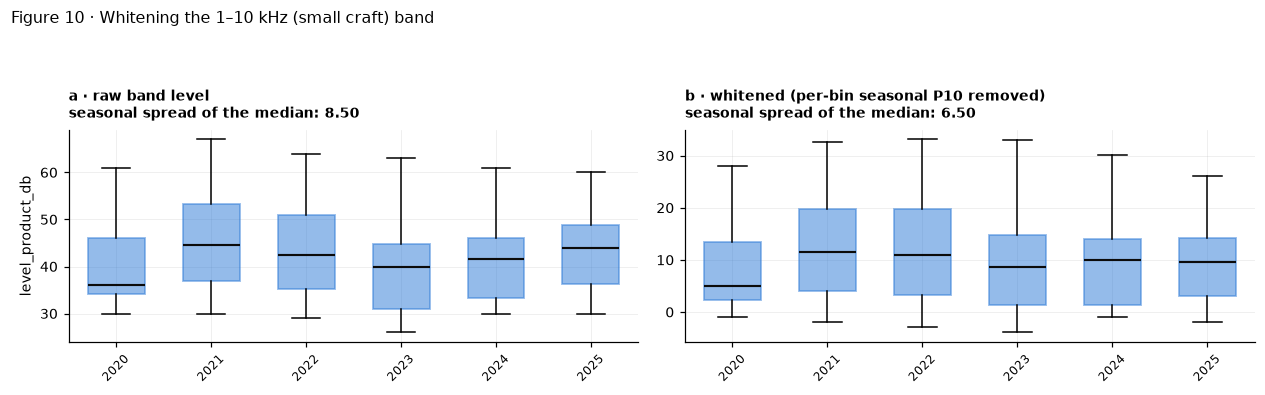

seasonal spread of the band median: raw 8.50 -> whitened 6.50 counts
Caveat this does NOT settle: a whitener fitted per season cannot also measure a real
between-season change in traffic. It buys threshold transferability, not a trend.


In [18]:
lo_p, hi_p = bins_for(BANDS[PRIMARY][0])
raw_file = np.median(band_lvl[PRIMARY], axis=1)

# Per-bin seasonal floor (a LOW percentile, so a pass does not set its own baseline),
# then re-reduce the whitened surface over the same band.
white_file = np.empty_like(raw_file)
for y in YEARS:
    sel = np.array([year_of(p) == y for p in SAMPLE])
    floor_bin = np.percentile(med_spec[sel][:, lo_p:hi_p], 10.0, axis=0)
    white_file[sel] = np.median(med_spec[sel][:, lo_p:hi_p] - floor_bin, axis=1)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6), sharey=False)
for k, (vals, title) in enumerate([(raw_file, "a · raw band level"),
                                   (white_file, "b · whitened (per-bin seasonal P10 removed)")]):
    data = [vals[[year_of(p) == y for p in SAMPLE]] for y in YEARS]
    bp = ax[k].boxplot(data, tick_labels=YEARS, patch_artist=True, widths=0.6,
                       medianprops=dict(color="#0b0b0b", lw=1.4),
                       flierprops=dict(marker="o", ms=2.5, mfc="#2a78d6", mec="none", alpha=0.5))
    for box in bp["boxes"]:
        box.set(facecolor="#2a78d6", alpha=0.5, edgecolor="#2a78d6", linewidth=1.2)
    spread = max(np.median(d) for d in data) - min(np.median(d) for d in data)
    ax[k].set_title(f"{title}\nseasonal spread of the median: {spread:.2f}", fontsize=9)
    ax[k].tick_params(axis="x", labelrotation=45, labelsize=8)
ax[0].set_ylabel("level_product_db")
fig.suptitle(f"Figure 10 · Whitening the {PRIMARY} band", x=0.005, ha="left", fontsize=10.5)
fig.tight_layout(rect=(0, 0, 1, 0.9)); plt.show()

r_sp = max(np.median(raw_file[[year_of(p)==y for p in SAMPLE]]) for y in YEARS) - \
       min(np.median(raw_file[[year_of(p)==y for p in SAMPLE]]) for y in YEARS)
w_sp = max(np.median(white_file[[year_of(p)==y for p in SAMPLE]]) for y in YEARS) - \
       min(np.median(white_file[[year_of(p)==y for p in SAMPLE]]) for y in YEARS)
print(f"seasonal spread of the band median: raw {r_sp:.2f} -> whitened {w_sp:.2f} counts")
print("Caveat this does NOT settle: a whitener fitted per season cannot also measure a real")
print("between-season change in traffic. It buys threshold transferability, not a trend.")

## 11 · Integration check against `boatphone.features`

Every figure above is computed locally, on purpose. `features.py` and `overpasses.py` are owned by
the B5 workstream and were untracked when this notebook was written (both are committed as of
`329b7cd`); a notebook that breaks on their API churn is a nuisance rather than a contribution.

This **single cell** is the only place that calls into them. It re-derives one band-level series
through `features.band_level_series` and compares it against the local computation. A mismatch is
informative either way, so it is printed rather than swallowed.

In [19]:
from boatphone import features, fft_io

probe = sorted(window_files(T0)[0], key=stamp_of)[0]
prod = fft_io.read_fft_gz(probe)
series = features.band_level_series(prod, BANDS[PRIMARY][0])
local = np.median(read_product(probe).astype(float)[:, lo_p:hi_p], axis=1)

print(f"features.band_level_series -> statistic = {series.statistic!r}")
print(f"  n_bins_in_band  : {series.n_bins_in_band}   (local band slice: {hi_p - lo_p} bins)")
print(f"  fraction at floor: {series.fraction_in_band_at_floor:.5f}")
print(f"  decidecade_resolvable: {series.decidecade_resolvable}")

d = np.abs(series.level_product_db - local)
print(f"\nmax |features - local median| = {d.max():.3f} counts")
if d.max() > 1e-9:
    print("  MISMATCH. The band slices differ (features carries the ±125 Hz axis uncertainty,")
    print(f"  which widens the band by up to {AXIS_UNC/BIN_HZ:.1f} bins per edge), and/or the")
    print("  reduction differs. Note config.FFT_BAND_LEVEL_STATISTIC is")
    print(f"  {config.FFT_BAND_LEVEL_STATISTIC!r} -- check that against what the code computes.")
else:
    print("  Identical.")

features.band_level_series -> statistic = 'median_of_product_db'
  n_bins_in_band  : 37   (local band slice: 37 bins)
  fraction at floor: 0.00000
  decidecade_resolvable: True

max |features - local median| = 0.000 counts
  Identical.


## 12 · What to take from this

**Recommended (rendered above).** LTSA (Fig 2); SPD with exact integer densities and exceedance
percentiles (Fig 3); the control band carried on every cross-year figure (Figs 4–5); data-quality
tracks with each claimed bound drawn (Fig 6); the ping as a free time-base verifier (Fig 7); the
matched WAV↔product pair for the counts→dB scale (Fig 8); scoped stamp panels with a shifted-marker
null (Fig 9); per-bin whitening before any threshold (Fig 10).

**Not done here, and why** — see `references/hydrophone-methods-brief.md` §5 for the full list with
the wrong number each would produce. The short version: no diel analysis (the corpus is a 2.5 h/day
strip); no decidecade or hybrid-millidecade bands (they are power sums and the scale is unknown);
no DEMON (4 Hz frame rate vs a 100–300 Hz blade rate); no ACI or NDSI (they are not invariant under
an unknown monotone scale, and they always produce output regardless); no censoring-aware
estimators (in-band censoring is ~0.05%, not 18.7%); no Lloyd-mirror ranging (no hydrophone depth
constant exists).

**Findings for whoever owns B5** — see the brief's §1.3 and §1.5. The load-bearing one: the B5
viability gate scores at a **fixed +10 dB excess**, and the seasonal spread of the band median
measured above is **8.5 counts**. Those are comparable, and the gate's 13 windows do not span the
seasonal range — so the same vessel could clear the threshold in one season and miss it in another.
Behind that: the "18.7% censored" figure is the anti-alias dead band rather than censoring and is
still asserted in five places in the code and in decision 0015; decision 0014's bin-0 and dead-band
bounds fail on most corpus files; and `corpus_file_index` still double-counts 90 windows.

**Nothing here is a decision.** These are suggestions, with the evidence attached so they can be
argued with.